# Agente Rafa para Connect-4

Este notebook documenta el diseno, entrenamiento y evaluacion del agente Rafa. La idea central es usar **trial-based online policy improvement (TBOPI)**: en cada estado se corre un subproceso local con UCB para mejorar la accion elegida, y una Q-table global aprendida por self-play sirve como memoria/prior.

La entrega no presenta al agente como una caja negra. Se comparan versiones internas del mismo agente para medir el aporte de la memoria global y de las mejoras introducidas en la version final.

## 1. Metodologia

### Entrenamiento

El entrenamiento principal fue por **self-play** porque asumimos que no conocemos la politica optima ni tenemos un experto disponible. El agente genera experiencia jugando contra copias de si mismo y actualiza una Q-table global a partir del resultado de partidas completas.

- Ronda 1: **50,000 partidas** de self-play para construir `RafaQ`.
- Presupuesto ronda 1: aproximadamente **24 inner rollouts** por estado.
- Ronda 2: **50,000 partidas** adicionales con `RafaImproved`.
- Presupuesto ronda 2: aproximadamente **8 inner rollouts** por estado; aunque eran menos, los rollouts fueron de mejor calidad porque usaban politica heuristica.
- Total aproximado: **100,000 partidas** de self-play acumuladas.
- Recompensa final: `+1` victoria, `0` empate, `-1` derrota.
- Memoria: `groups/Rafa/rafa_q_values.pkl`.

### Versiones comparadas

| Version | Memoria global | Rollout | Seleccion final |
|---|---:|---|---|
| `RafaBase` | No | Aleatorio | Proporcional a visitas |
| `RafaQ` | Si, prior suave | Aleatorio | Proporcional a visitas |
| `RafaImproved` / `Rafa` | Si, prior mas fuerte | Heuristico | Robusta por visitas y valor |

`RafaImproved` es la policy final: conserva TBOPI, pero mejora la calidad de los inner trials y reduce la variancia de la accion final.

### Metodologia experimental

Los experimentos son ablations controladas: se cambian pocos componentes a la vez para poder atribuir la mejora. Primero se compara `RafaBase` contra `RafaQ` para aislar el efecto de la memoria global. Luego se compara `RafaQ` contra `RafaImproved` para aislar el efecto de rollouts heuristicos, prior mas fuerte y seleccion robusta. Finalmente se hacen sweeps de `total_time` y `global_prior_visits` para ver si la mejora depende del presupuesto de computo o del peso de la memoria.

## 2. Setup y carga de datos

In [42]:
from pathlib import Path
import csv
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

def find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "connect4").exists() and (path / "groups").exists():
            return path
    raise FileNotFoundError("No pude encontrar la raiz del repo Connect4RL.")

ROOT = find_repo_root(Path.cwd().resolve())
RAFA_DIR = ROOT / "groups" / "Rafa"
ANALYTICS = RAFA_DIR / "analytics"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

print("ROOT:", ROOT)
print("ANALYTICS:", ANALYTICS)

ROOT: C:\Users\rafae\Documents\Connect4RL
ANALYTICS: C:\Users\rafae\Documents\Connect4RL\groups\Rafa\analytics


In [43]:
def read_csv_if_exists(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()

def load_games_csv(path: Path) -> pd.DataFrame:
    """Carga games.csv aun si mezcla formato antiguo y nuevo con run_started_at."""
    if not path.exists():
        return pd.DataFrame()
    rows = []
    with path.open(newline="", encoding="utf-8") as f:
        reader = csv.reader(f)
        try:
            header = next(reader)
        except StopIteration:
            return pd.DataFrame()
        for raw in reader:
            if not raw or raw == header:
                continue
            if len(raw) == len(header):
                row = dict(zip(header, raw))
                row.setdefault("run_started_at", "")
            elif len(raw) == len(header) + 1:
                row = {"run_started_at": raw[0]}
                row.update(dict(zip(header, raw[1:])))
            else:
                continue
            rows.append(row)
    df = pd.DataFrame(rows)
    for col in ["game", "winner_color", "moves_count", "red_time", "yellow_time"]:
        if col in df:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

def plot_match_results(matches: pd.DataFrame, title: str) -> None:
    if matches.empty:
        print("No hay matches para:", title)
        return
    display(matches)
    labels = matches["agent_a"] + " vs " + matches["agent_b"]
    a_rate = matches["a_wins"] / matches["games"]
    draw_rate = matches["draws"] / matches["games"]
    b_rate = matches["b_wins"] / matches["games"]
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(labels, a_rate, label="agent_a wins", color="#2f6f4e")
    ax.bar(labels, draw_rate, bottom=a_rate, label="draws", color="#8c8c8c")
    ax.bar(labels, b_rate, bottom=a_rate + draw_rate, label="agent_b wins", color="#b54c3f")
    ax.set_ylim(0, 1.02)
    ax.set_ylabel("Proporcion")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=20)
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_ranking(ranking: pd.DataFrame, title: str) -> None:
    if ranking.empty:
        print("No hay ranking para:", title)
        return
    display(ranking)
    data = ranking.sort_values("points_per_game", ascending=False)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(data["agent"], data["points_per_game"], color="#345995")
    ax.set_ylim(0, 1.02)
    ax.set_ylabel("Puntos por partida")
    ax.set_title(title)
    for i, row in enumerate(data.itertuples()):
        ax.text(i, row.points_per_game + 0.02, f"{row.points_per_game:.2f}", ha="center")
    plt.tight_layout()
    plt.show()

## 3. Memoria aprendida

La Q-table no intenta cubrir todo Connect-4. Funciona como memoria sobre estados visitados por self-play inteligente. Esa memoria se usa como prior para el UCB local.

Estados con memoria: 1,989,221
Pares (estado, accion): 2,171,168


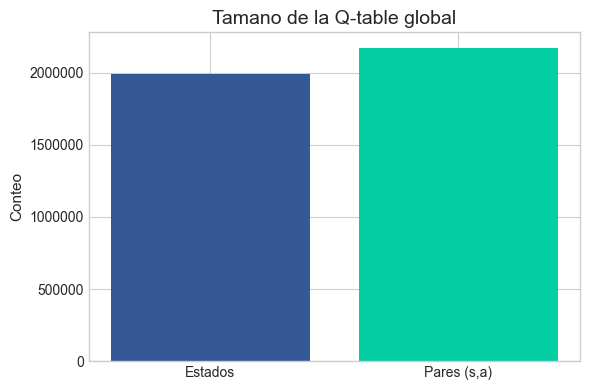

In [44]:
qtable_path = RAFA_DIR / "rafa_q_values.pkl"
if qtable_path.exists():
    with qtable_path.open("rb") as f:
        payload = pickle.load(f)
    q_table = payload.get("q_table", payload) if isinstance(payload, dict) else payload
    q_states = len(q_table)
    q_entries = sum(len(actions) for actions in q_table.values())
    print(f"Estados con memoria: {q_states:,}")
    print(f"Pares (estado, accion): {q_entries:,}")
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(["Estados", "Pares (s,a)"], [q_states, q_entries], color=["#345995", "#03cea4"])
    ax.set_title("Tamano de la Q-table global")
    ax.set_ylabel("Conteo")
    ax.ticklabel_format(style="plain", axis="y")
    plt.tight_layout()
    plt.show()
else:
    print("No se encontro", qtable_path)

## 4. Cobertura de memoria y oportunidades de mejora

Para entender que falta por mejorar, no basta con mirar victorias. Tambien medimos en que profundidades del juego la Q-table tiene memoria. La cobertura se calcula como estados aprendidos por numero de fichas dividido entre un limite superior de estados posibles con gravedad para esa misma profundidad.

Esta metrica es una aproximacion: los CSV actuales no guardan la secuencia de jugadas, entonces no podemos medir todavia el hit-rate exacto de estados vistos durante cada partida. Aun asi, la grafica muestra donde la memoria es densa y donde el agente vuelve a depender casi totalmente de TBOPI online.

,pieces,states,gravity_upper_bound,coverage_pct,coverage_ppm,avg_actions_per_state,avg_visits_per_state
0,0,1,1,100.000000,1000000.00,7.00,119084.0
1,1,7,7,100.000000,1000000.00,7.00,17012.0
2,2,49,56,87.500000,875000.00,7.00,2430.3
3,3,238,252,94.444444,944444.44,7.00,500.4
4,4,1120,1260,88.888889,888888.89,6.87,106.3
5,5,4224,4620,91.428571,914285.71,4.95,28.2
6,6,12820,18480,69.372294,693722.94,3.13,9.3
7,7,28413,59815,47.501463,475014.63,1.99,4.1
8,8,44338,206780,21.442112,214421.12,1.62,2.6
9,9,62105,605934,10.249466,102494.66,1.37,1.9


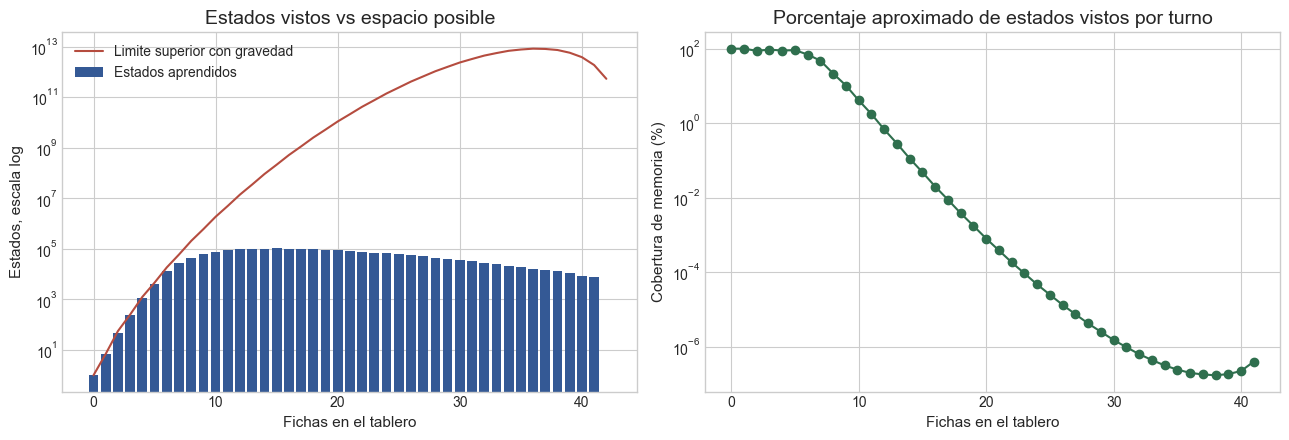

Profundidades con menor cobertura entre estados ya explorados:


,pieces,states,gravity_upper_bound,coverage_pct,coverage_ppm
38,38,12799,7422505398000,1.700000e-07,0.0017
37,37,14775,8164755937800,1.800000e-07,0.0018
39,39,10726,5789554210440,1.900000e-07,0.0019
36,36,16744,8385425017200,2.000000e-07,0.0020
40,40,8680,3859702806960,2.200000e-07,0.0022
35,35,18941,7754703113850,2.400000e-07,0.0024
34,34,21780,6893472773880,3.200000e-07,0.0032
41,41,7568,1883902560540,4.000000e-07,0.0040


In [45]:
from math import comb

def gravity_shape_counts(max_cols: int = 7, max_height: int = 6) -> list[int]:
    counts = [0] * (max_cols * max_height + 1)
    counts[0] = 1
    for _ in range(max_cols):
        nxt = [0] * len(counts)
        for total, count in enumerate(counts):
            if count == 0:
                continue
            for h in range(max_height + 1):
                if total + h < len(nxt):
                    nxt[total + h] += count
        counts = nxt
    return counts

if "q_table" not in globals() or not q_table:
    print("No hay Q-table cargada para analizar cobertura.")
else:
    shape_counts = gravity_shape_counts()
    rows = []
    for key, actions in q_table.items():
        pieces = sum(1 for value in key if value != 0)
        total_visits = sum(int(v[1]) for v in actions.values())
        rows.append({"pieces": pieces, "states": 1, "state_actions": len(actions), "visits": total_visits})
    depth = pd.DataFrame(rows).groupby("pieces", as_index=False).sum()
    possible = pd.DataFrame({
        "pieces": range(43),
        "gravity_upper_bound": [shape_counts[t] * comb(t, t // 2) for t in range(43)],
    })
    coverage = possible.merge(depth, on="pieces", how="left").fillna({"states": 0, "state_actions": 0, "visits": 0})
    coverage[["states", "state_actions", "visits"]] = coverage[["states", "state_actions", "visits"]].astype(int)
    coverage["coverage_pct"] = 100 * coverage["states"] / coverage["gravity_upper_bound"]
    coverage["coverage_ppm"] = 1_000_000 * coverage["states"] / coverage["gravity_upper_bound"]
    coverage["avg_actions_per_state"] = np.where(coverage["states"] > 0, coverage["state_actions"] / coverage["states"], 0)
    coverage["avg_visits_per_state"] = np.where(coverage["states"] > 0, coverage["visits"] / coverage["states"], 0)

    display_cols = ["pieces", "states", "gravity_upper_bound", "coverage_pct", "coverage_ppm", "avg_actions_per_state", "avg_visits_per_state"]
    display(coverage.loc[coverage["states"] > 0, display_cols].round({"coverage_pct": 6, "coverage_ppm": 2, "avg_actions_per_state": 2, "avg_visits_per_state": 1}))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].bar(coverage["pieces"], coverage["states"], color="#345995", label="Estados aprendidos")
    axes[0].plot(coverage["pieces"], coverage["gravity_upper_bound"], color="#b54c3f", label="Limite superior con gravedad")
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Fichas en el tablero")
    axes[0].set_ylabel("Estados, escala log")
    axes[0].set_title("Estados vistos vs espacio posible")
    axes[0].legend()

    plotted = coverage[coverage["states"] > 0]
    axes[1].plot(plotted["pieces"], plotted["coverage_pct"], marker="o", color="#2f6f4e")
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Fichas en el tablero")
    axes[1].set_ylabel("Cobertura de memoria (%)")
    axes[1].set_title("Porcentaje aproximado de estados vistos por turno")
    plt.tight_layout()
    plt.show()

    weak = coverage[(coverage["pieces"] >= 10) & (coverage["states"] > 0)].sort_values("coverage_pct").head(8)
    print("Profundidades con menor cobertura entre estados ya explorados:")
    display(weak[["pieces", "states", "gravity_upper_bound", "coverage_pct", "coverage_ppm"]].round({"coverage_pct": 8, "coverage_ppm": 4}))

### Uso del presupuesto de torneo

Ademas de cobertura, revisamos cuanto tiempo consume cada version. Si una politica mejora pero usa casi todo el presupuesto, la mejora puede no escalar; si usa poco tiempo y aun asi pierde, probablemente el problema esta en la calidad de los trials o en la cobertura de memoria.

,agent,games,avg_budget_used_pct,p95_budget_used_pct,avg_time_per_move,max_total_time,overtime_games
2,RafaQ,45,63.253,87.555,2.604,54.006,0
0,RafaBase,20,58.119,86.201,2.605,57.150,0
1,RafaImproved,45,56.842,86.141,2.359,55.057,0


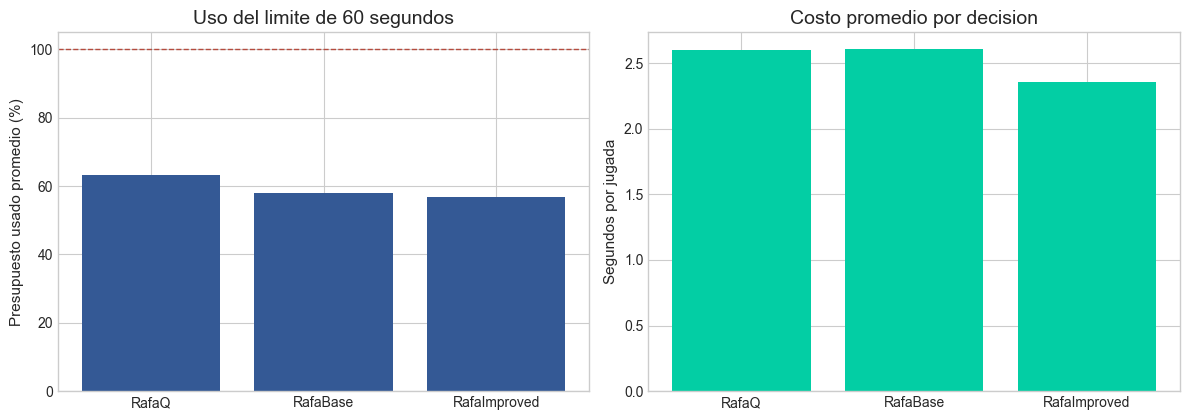

In [46]:
def agent_time_rows(games: pd.DataFrame, source: str) -> pd.DataFrame:
    if games.empty:
        return pd.DataFrame()
    rows = []
    for row in games.itertuples(index=False):
        moves = getattr(row, "moves_count", np.nan)
        red_turns = np.ceil(moves / 2) if pd.notna(moves) else np.nan
        yellow_turns = np.floor(moves / 2) if pd.notna(moves) else np.nan
        for color, turns in [("red", red_turns), ("yellow", yellow_turns)]:
            agent = getattr(row, color, None)
            total_time = getattr(row, f"{color}_time", np.nan)
            over_time = getattr(row, f"{color}_over_time", False)
            rows.append({
                "source": source,
                "agent": agent,
                "total_time": float(total_time) if pd.notna(total_time) else np.nan,
                "turns": float(turns) if pd.notna(turns) else np.nan,
                "time_per_move": float(total_time) / turns if pd.notna(total_time) and turns else np.nan,
                "budget_used_pct": 100 * float(total_time) / 60 if pd.notna(total_time) else np.nan,
                "over_time": str(over_time).lower() == "true",
            })
    return pd.DataFrame(rows)

time_data = pd.concat([
    agent_time_rows(load_games_csv(ANALYTICS / "version_ablation" / "games.csv"), "ablation"),
    agent_time_rows(load_games_csv(ANALYTICS / "improved_vs_q" / "games.csv"), "improved_vs_q"),
], ignore_index=True)

rafa_versions = ["RafaBase", "RafaQ", "RafaImproved"]
time_data = time_data[time_data["agent"].isin(rafa_versions)]
if time_data.empty:
    print("No hay datos de tiempo para analizar.")
else:
    time_summary = time_data.groupby("agent", as_index=False).agg(
        games=("agent", "size"),
        avg_budget_used_pct=("budget_used_pct", "mean"),
        p95_budget_used_pct=("budget_used_pct", lambda s: s.quantile(0.95)),
        avg_time_per_move=("time_per_move", "mean"),
        max_total_time=("total_time", "max"),
        overtime_games=("over_time", "sum"),
    ).sort_values("avg_budget_used_pct", ascending=False)
    display(time_summary.round(3))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
    axes[0].bar(time_summary["agent"], time_summary["avg_budget_used_pct"], color="#345995")
    axes[0].axhline(100, color="#b54c3f", linestyle="--", linewidth=1)
    axes[0].set_ylabel("Presupuesto usado promedio (%)")
    axes[0].set_title("Uso del limite de 60 segundos")

    axes[1].bar(time_summary["agent"], time_summary["avg_time_per_move"], color="#03cea4")
    axes[1].set_ylabel("Segundos por jugada")
    axes[1].set_title("Costo promedio por decision")
    plt.tight_layout()
    plt.show()

### Lectura de mejora

- Como cobertura cae fuerte despues de cierto numero de fichas, el agente necesita mas self-play dirigido a medio/final de partida.
- Una mejora clara seria canonicalizar simetria horizontal: un tablero y su espejo compartirian memoria, reduciendo casi a la mitad muchos estados equivalentes.


## 5. Validacion minima del reto: Random y self-play

Evidencia contra el jugador aleatorio y tambien autodesempeno: que pasa cuando el agente juega contra alguien que aplica exactamente la misma estrategia. 

,version,color,opponent,total_time,games,wins,losses,draws,win_rate,loss_rate,draw_rate,avg_moves
0,RafaBase,red,Random,2.0,20,20,0,0,1.0,0.0,0.0,10.1
1,RafaBase,yellow,Random,2.0,20,20,0,0,1.0,0.0,0.0,15.6
2,RafaQ,red,Random,2.0,20,20,0,0,1.0,0.0,0.0,12.8
3,RafaQ,yellow,Random,2.0,20,20,0,0,1.0,0.0,0.0,13.9
4,RafaImproved,red,Random,2.0,20,20,0,0,1.0,0.0,0.0,12.4
5,RafaImproved,yellow,Random,2.0,20,20,0,0,1.0,0.0,0.0,16.7


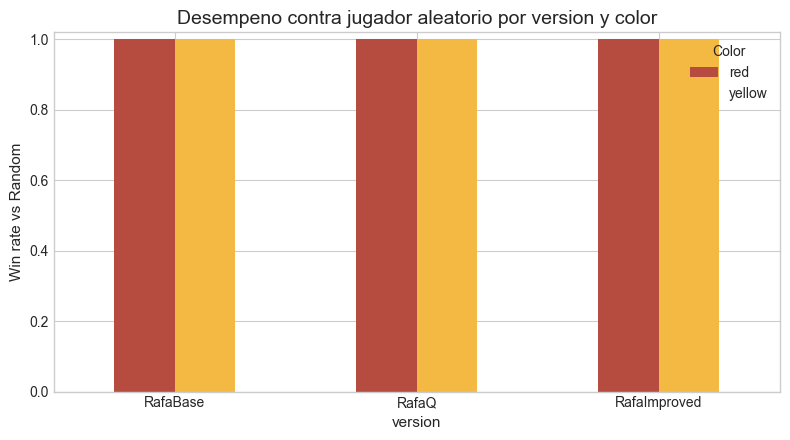

,red,yellow
version,,
RafaBase,0.000,0.000
RafaQ,0.000,0.000
RafaImproved,0.000,0.000


,version,total_time,games,red_wins,yellow_wins,draws,red_win_rate,yellow_win_rate,draw_rate,avg_moves
0,RafaBase,2.0,20,12,6,2,0.60,0.30,0.10,27.70
1,RafaQ,2.0,20,10,7,3,0.50,0.35,0.15,27.80
2,RafaImproved,2.0,20,9,7,4,0.45,0.35,0.20,27.55


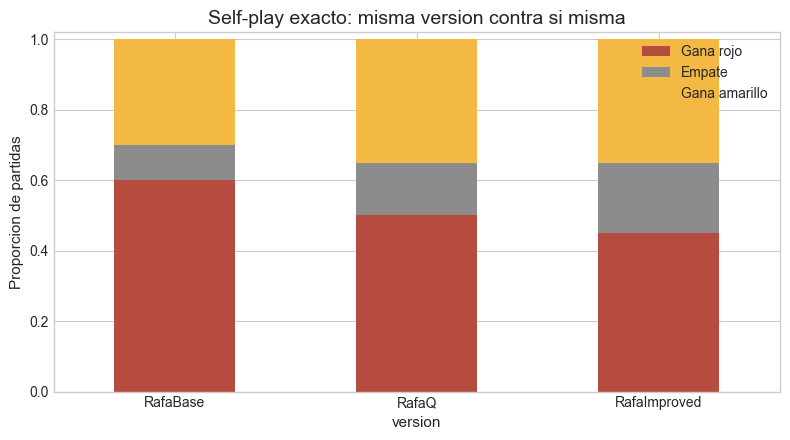

In [47]:
reto_dir = ANALYTICS / "reto_requirements"
random_vs_versions = read_csv_if_exists(reto_dir / "random_vs_versions.csv")
self_play_versions = read_csv_if_exists(reto_dir / "self_play_versions.csv")

version_order = ["RafaBase", "RafaQ", "RafaImproved"]

if random_vs_versions.empty:
    print("No hay datos vs Random. Genera datos con el comando de la seccion final.")
else:
    display(random_vs_versions)
    pivot = random_vs_versions.pivot(index="version", columns="color", values="win_rate").reindex(version_order)
    ax = pivot.plot(kind="bar", figsize=(8, 4.5), color=["#b54c3f", "#f4b942"])
    ax.set_ylim(0, 1.02)
    ax.set_ylabel("Win rate vs Random")
    ax.set_title("Desempeno contra jugador aleatorio por version y color")
    ax.legend(title="Color")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    loss_pivot = random_vs_versions.pivot(index="version", columns="color", values="loss_rate").reindex(version_order)
    display(loss_pivot.rename_axis(None, axis=1).round(3).style.format("{:.3f}").set_caption("Loss rate vs Random; idealmente debe ser 0 en ambos colores"))

if self_play_versions.empty:
    print("No hay datos de self-play exacto. Genera datos con el comando de la seccion final.")
else:
    display(self_play_versions)
    data = self_play_versions.set_index("version").reindex(version_order)
    stacked = data[["red_win_rate", "draw_rate", "yellow_win_rate"]]
    ax = stacked.plot(kind="bar", stacked=True, figsize=(8, 4.5), color=["#b54c3f", "#8c8c8c", "#f4b942"])
    ax.set_ylim(0, 1.02)
    ax.set_ylabel("Proporcion de partidas")
    ax.set_title("Self-play exacto: misma version contra si misma")
    ax.legend(["Gana rojo", "Empate", "Gana amarillo"], loc="upper right")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 6. Curva de aprendizaje offline

Como no se guardaron snapshots historicos de las rondas completas de 50k y 100k partidas, esta curva se genera con un entrenamiento reproducible mas pequeno desde cero. Su objetivo no es reemplazar el entrenamiento grande, sino evidenciar la relacion entre recursos offline, tamano de memoria y desempeno contra Random.

,trained_games,q_states,q_entries,random_red_win_rate,random_red_loss_rate,random_yellow_win_rate,random_yellow_loss_rate
0,0,0,0,1.0,0.0,0.9,0.1
1,50,1253,1305,1.0,0.0,1.0,0.0
2,100,2391,2500,1.0,0.0,1.0,0.0
3,250,5679,5952,1.0,0.0,0.9,0.1
4,500,9624,10126,1.0,0.0,1.0,0.0


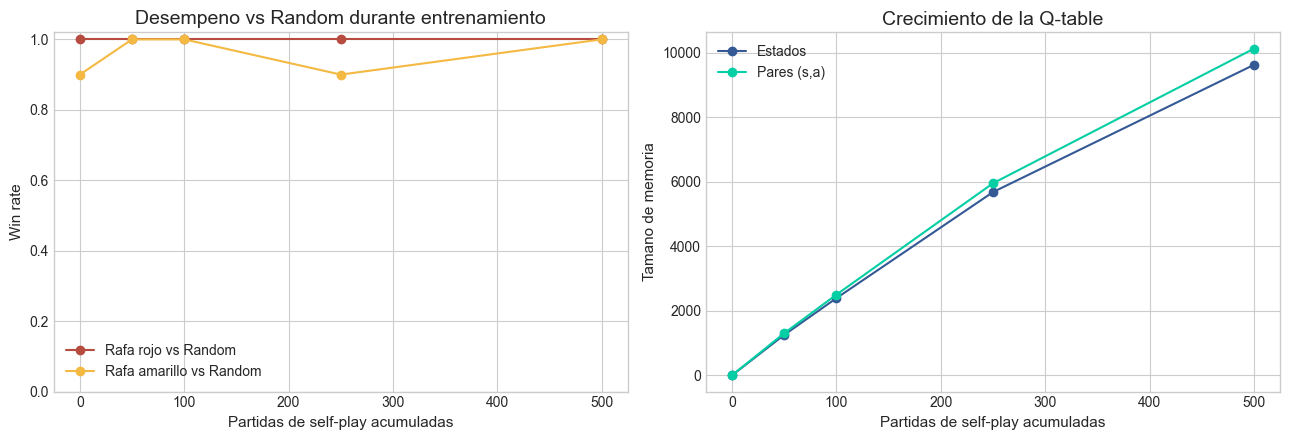

,trained_games,new_states,new_entries
0,0,0,0
1,50,1253,1305
2,100,1138,1195
3,250,3288,3452
4,500,3945,4174


Como los estados nuevos siguen creciendo casi linealmente, el entrenamiento todavia esta explorando zonas no cubiertas del espacio de estados.


In [49]:
training_curve = read_csv_if_exists(reto_dir / "training_curve.csv")
if training_curve.empty:
    print("No hay curva de entrenamiento. Genera datos con el comando de la seccion final.")
else:
    display(training_curve)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(training_curve["trained_games"], training_curve["random_red_win_rate"], marker="o", label="Rafa rojo vs Random", color="#b54c3f")
    axes[0].plot(training_curve["trained_games"], training_curve["random_yellow_win_rate"], marker="o", label="Rafa amarillo vs Random", color="#f4b942")
    axes[0].set_ylim(0, 1.02)
    axes[0].set_xlabel("Partidas de self-play acumuladas")
    axes[0].set_ylabel("Win rate")
    axes[0].set_title("Desempeno vs Random durante entrenamiento")
    axes[0].legend()

    axes[1].plot(training_curve["trained_games"], training_curve["q_states"], marker="o", label="Estados", color="#345995")
    axes[1].plot(training_curve["trained_games"], training_curve["q_entries"], marker="o", label="Pares (s,a)", color="#03cea4")
    axes[1].set_xlabel("Partidas de self-play acumuladas")
    axes[1].set_ylabel("Tamano de memoria")
    axes[1].set_title("Crecimiento de la Q-table")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    if len(training_curve) >= 2:
        growth = training_curve.copy()
        growth["new_states"] = growth["q_states"].diff().fillna(growth["q_states"])
        growth["new_entries"] = growth["q_entries"].diff().fillna(growth["q_entries"])
        display(growth[["trained_games", "new_states", "new_entries"]].astype(int))
        print("Como los estados nuevos siguen creciendo casi linealmente, el entrenamiento todavia esta explorando zonas no cubiertas del espacio de estados.")

## 7. Ablation principal: Base -> Q -> Improved

Este es el experimento central: comparar versiones internas del mismo agente, no contra otros grupos.

,agent,run_started_at,points,games,wins,losses,draws,win_rate,points_per_game,red_wins,red_games,yellow_wins,yellow_games,over_time_games,invalid_games
0,RafaImproved,2026-05-25 15:30:26,12.5,20,12,7,1,0.60,0.625,5,10,7,10,0,0
1,RafaQ,2026-05-25 15:30:26,10.0,20,10,10,0,0.50,0.500,6,10,4,10,0,0
2,RafaBase,2026-05-25 15:30:26,7.5,20,7,12,1,0.35,0.375,5,10,2,10,0,0


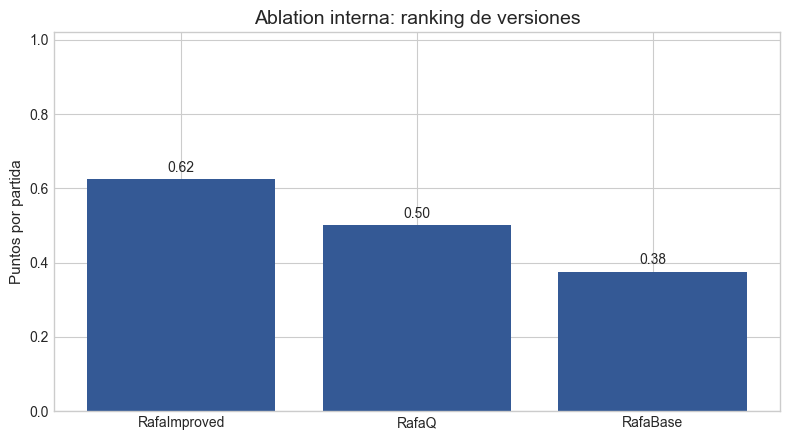

,run_started_at,agent_a,agent_b,a_wins,b_wins,draws,games
0,2026-05-25 15:05:39,RafaBase,RafaImproved,4,5,1,10
1,2026-05-25 15:17:32,RafaBase,RafaQ,3,7,0,10
2,2026-05-25 15:30:26,RafaImproved,RafaQ,7,3,0,10


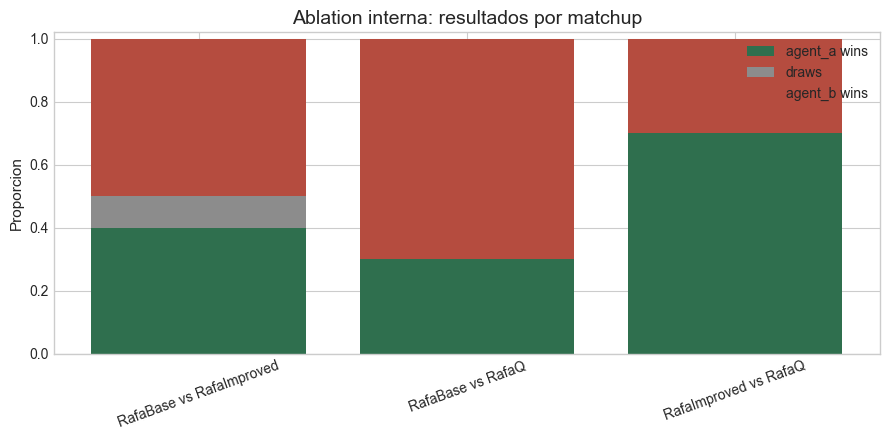

In [50]:
version_dir = ANALYTICS / "version_ablation"
version_ranking = read_csv_if_exists(version_dir / "ranking.csv")
version_matches = read_csv_if_exists(version_dir / "matches.csv")
plot_ranking(version_ranking, "Ablation interna: ranking de versiones")
plot_match_results(version_matches, "Ablation interna: resultados por matchup")

## 8. RafaImproved vs RafaQ

Este experimento aisla el aporte de las mejoras online de `RafaImproved`, porque ambas versiones usan Q-table global, pero `RafaImproved` usa rollouts heuristicos, prior mas fuerte y seleccion final robusta.

,agent,run_started_at,points,games,wins,losses,draws,win_rate,points_per_game,red_wins,red_games,yellow_wins,yellow_games,over_time_games,invalid_games
0,RafaImproved,2026-05-25 16:02:53,15.0,25,15,10,0,0.6,0.6,8,13,7,12,0,0
1,RafaQ,2026-05-25 16:02:53,10.0,25,10,15,0,0.4,0.4,5,12,5,13,0,0


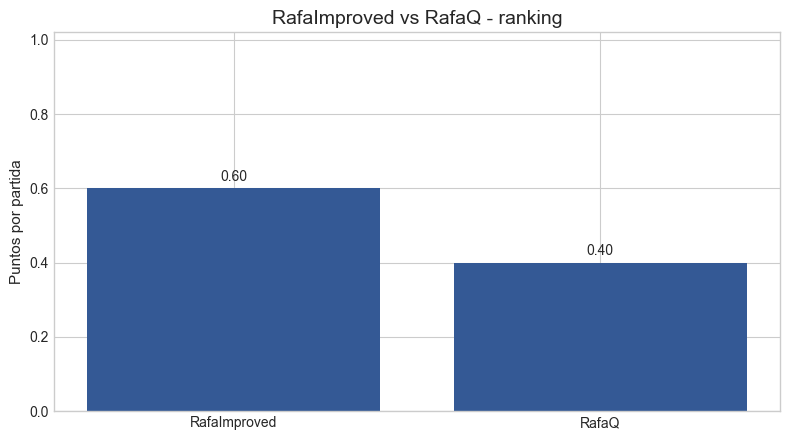

,run_started_at,agent_a,agent_b,a_wins,b_wins,draws,games
0,2026-05-25 16:02:53,RafaImproved,RafaQ,15,10,0,25


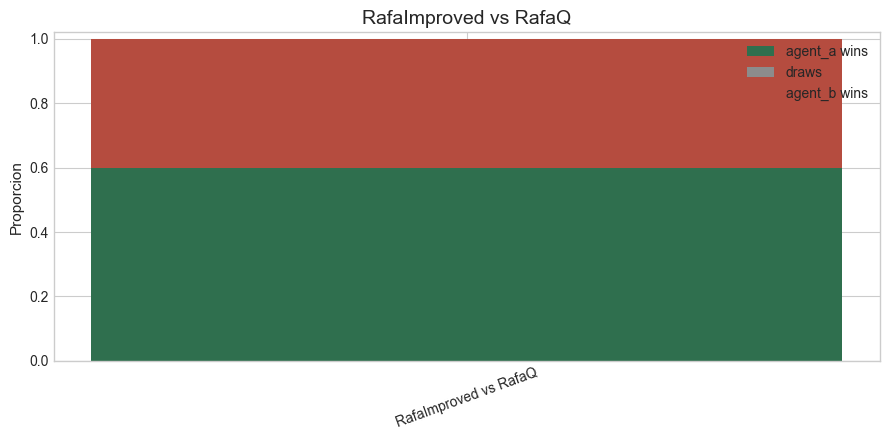

In [51]:
improved_vs_q_dir = ANALYTICS / "improved_vs_q"
improved_vs_q_ranking = read_csv_if_exists(improved_vs_q_dir / "ranking.csv")
improved_vs_q_matches = read_csv_if_exists(improved_vs_q_dir / "matches.csv")
plot_ranking(improved_vs_q_ranking, "RafaImproved vs RafaQ - ranking")
plot_match_results(improved_vs_q_matches, "RafaImproved vs RafaQ")

## 9. Sweep de hiperparametros

Aqui variamos el presupuesto online (`total_time`) y el peso de memoria (`global_prior_visits`). Esto muestra si la mejora depende de recursos y configuracion. Para que las graficas sean legibles, se separan los enfrentamientos contra `RafaBase` por agente y se deja aparte la comparacion directa `RafaImproved` vs `RafaQ`.

,agent,baseline,total_time,global_prior_visits,games,agent_wins,baseline_wins,draws,agent_win_rate,baseline_win_rate,draw_rate,points_per_game
0,RafaQ,RafaBase,0.3,1,10,6,3,1,0.6,0.3,0.1,0.65
8,RafaQ,RafaBase,1.0,1,10,4,6,0,0.4,0.6,0.0,0.40
16,RafaQ,RafaBase,2.0,1,10,3,7,0,0.3,0.7,0.0,0.30
24,RafaQ,RafaBase,10.0,1,10,3,5,2,0.3,0.5,0.2,0.40
32,RafaQ,RafaBase,60.0,1,10,6,4,0,0.6,0.4,0.0,0.60
2,RafaQ,RafaBase,0.3,5,10,5,5,0,0.5,0.5,0.0,0.50
10,RafaQ,RafaBase,1.0,5,10,6,4,0,0.6,0.4,0.0,0.60
18,RafaQ,RafaBase,2.0,5,10,5,4,1,0.5,0.4,0.1,0.55
26,RafaQ,RafaBase,10.0,5,10,7,3,0,0.7,0.3,0.0,0.70
34,RafaQ,RafaBase,60.0,5,10,8,2,0,0.8,0.2,0.0,0.80


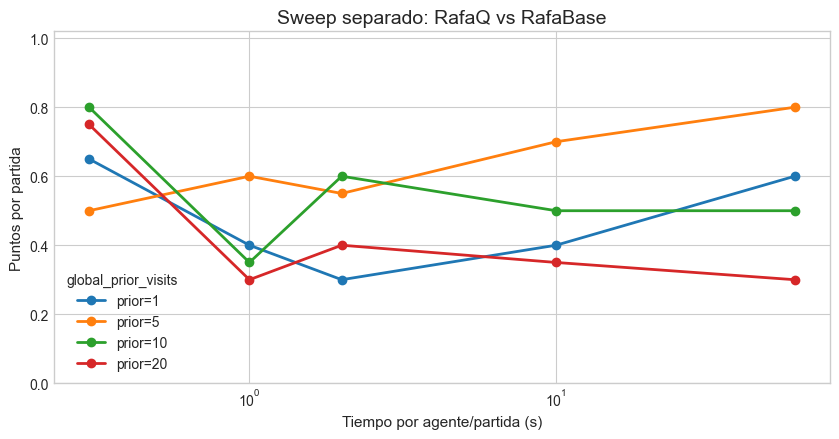

total_time,0.3,1.0,2.0,10.0,60.0
global_prior_visits,,,,,
1,0.65,0.40,0.30,0.40,0.6
5,0.50,0.60,0.55,0.70,0.8
10,0.80,0.35,0.60,0.50,0.5
20,0.75,0.30,0.40,0.35,0.3


,agent,baseline,total_time,global_prior_visits,games,agent_wins,baseline_wins,draws,agent_win_rate,baseline_win_rate,draw_rate,points_per_game
1,RafaImproved,RafaBase,0.3,1,10,8,2,0,0.8,0.2,0.0,0.80
9,RafaImproved,RafaBase,1.0,1,10,6,3,1,0.6,0.3,0.1,0.65
17,RafaImproved,RafaBase,2.0,1,10,7,2,1,0.7,0.2,0.1,0.75
25,RafaImproved,RafaBase,10.0,1,10,7,3,0,0.7,0.3,0.0,0.70
33,RafaImproved,RafaBase,60.0,1,10,7,3,0,0.7,0.3,0.0,0.70
3,RafaImproved,RafaBase,0.3,5,10,5,5,0,0.5,0.5,0.0,0.50
11,RafaImproved,RafaBase,1.0,5,10,8,2,0,0.8,0.2,0.0,0.80
19,RafaImproved,RafaBase,2.0,5,10,7,3,0,0.7,0.3,0.0,0.70
27,RafaImproved,RafaBase,10.0,5,10,7,2,1,0.7,0.2,0.1,0.75
35,RafaImproved,RafaBase,60.0,5,10,6,4,0,0.6,0.4,0.0,0.60


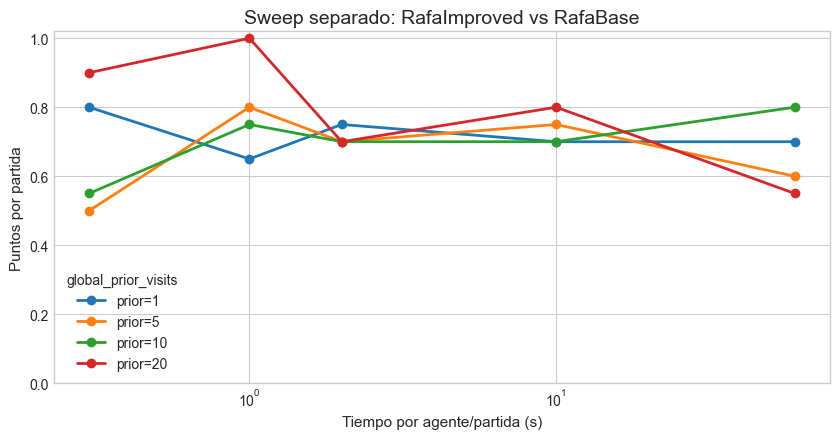

total_time,0.3,1.0,2.0,10.0,60.0
global_prior_visits,,,,,
1,0.80,0.65,0.75,0.70,0.70
5,0.50,0.80,0.70,0.75,0.60
10,0.55,0.75,0.70,0.70,0.80
20,0.90,1.00,0.70,0.80,0.55


,agent,baseline,total_time,global_prior_visits,points_per_game,agent_wins,baseline_wins,draws
15,RafaImproved,RafaBase,1.0,20,1.0,10,0,0
4,RafaQ,RafaBase,0.3,10,0.8,8,2,0


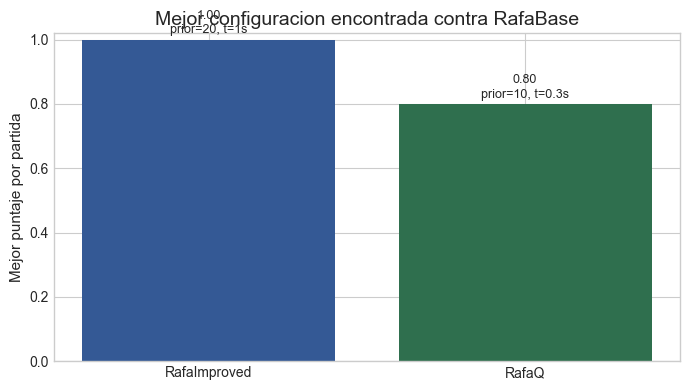

,agent,baseline,total_time,global_prior_visits,games,agent_wins,baseline_wins,draws,agent_win_rate,baseline_win_rate,draw_rate,points_per_game
0,RafaImproved,RafaQ,0.3,1,10,6,4,0,0.6,0.4,0.0,0.60
4,RafaImproved,RafaQ,1.0,1,10,6,4,0,0.6,0.4,0.0,0.60
8,RafaImproved,RafaQ,2.0,1,10,6,4,0,0.6,0.4,0.0,0.60
12,RafaImproved,RafaQ,10.0,1,10,6,4,0,0.6,0.4,0.0,0.60
16,RafaImproved,RafaQ,60.0,1,10,6,4,0,0.6,0.4,0.0,0.60
1,RafaImproved,RafaQ,0.3,5,10,9,1,0,0.9,0.1,0.0,0.90
5,RafaImproved,RafaQ,1.0,5,10,8,2,0,0.8,0.2,0.0,0.80
9,RafaImproved,RafaQ,2.0,5,10,7,3,0,0.7,0.3,0.0,0.70
13,RafaImproved,RafaQ,10.0,5,10,5,5,0,0.5,0.5,0.0,0.50
17,RafaImproved,RafaQ,60.0,5,10,6,4,0,0.6,0.4,0.0,0.60


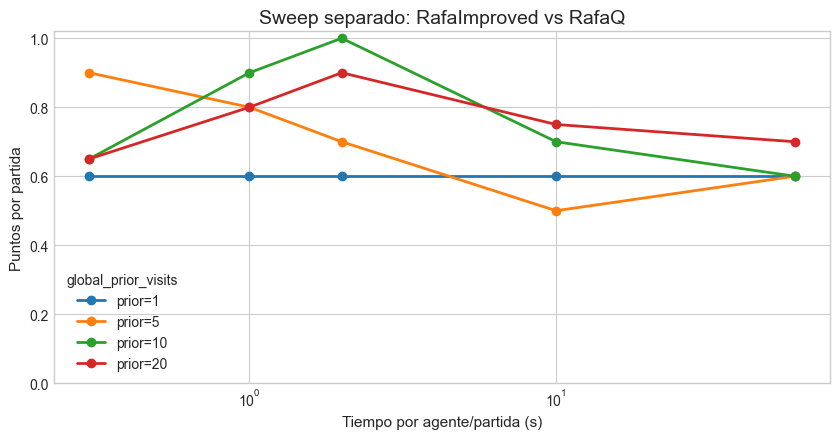

total_time,0.3,1.0,2.0,10.0,60.0
global_prior_visits,,,,,
1,0.60,0.6,0.6,0.60,0.6
5,0.90,0.8,0.7,0.50,0.6
10,0.65,0.9,1.0,0.70,0.6
20,0.65,0.8,0.9,0.75,0.7


,agent,baseline,total_time,global_prior_visits,points_per_game,agent_wins,baseline_wins,draws
10,RafaImproved,RafaQ,2.0,10,1.0,10,0,0


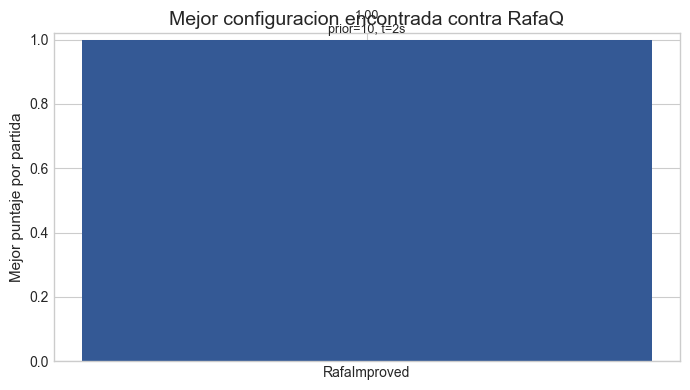

In [52]:
version_sweep = read_csv_if_exists(ANALYTICS / "version_sweep" / "version_sweep.csv")
version_sweep_vs_q = read_csv_if_exists(ANALYTICS / "version_sweep_vs_q" / "version_sweep.csv")

def plot_single_agent_sweep(df: pd.DataFrame, agent: str, title: str) -> None:
    data = df[df["agent"] == agent].copy()
    if data.empty:
        print("No hay datos para:", title)
        return
    display(data.sort_values(["global_prior_visits", "total_time"]))
    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    for prior, prior_data in data.groupby("global_prior_visits"):
        prior_data = prior_data.sort_values("total_time")
        ax.plot(prior_data["total_time"], prior_data["points_per_game"], marker="o", linewidth=2, label=f"prior={prior}")
    ax.set_xscale("log")
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("Tiempo por agente/partida (s)")
    ax.set_ylabel("Puntos por partida")
    ax.set_title(title)
    ax.legend(title="global_prior_visits")
    plt.tight_layout()
    plt.show()
    pivot = data.pivot_table(index="global_prior_visits", columns="total_time", values="points_per_game", aggfunc="mean")
    display(pivot.round(3))

def plot_sweep_best_config(df: pd.DataFrame, title: str) -> None:
    if df.empty:
        print("No hay datos para:", title)
        return
    best = df.sort_values("points_per_game", ascending=False).groupby("agent", as_index=False).head(1)
    display(best[["agent", "baseline", "total_time", "global_prior_visits", "points_per_game", "agent_wins", "baseline_wins", "draws"]])
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(best["agent"], best["points_per_game"], color=["#345995", "#2f6f4e"][: len(best)])
    ax.set_ylim(0, 1.02)
    ax.set_ylabel("Mejor puntaje por partida")
    ax.set_title(title)
    for i, row in enumerate(best.itertuples()):
        ax.text(i, row.points_per_game + 0.02, f"{row.points_per_game:.2f}\nprior={row.global_prior_visits}, t={row.total_time:g}s", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()

if version_sweep.empty:
    print("No hay datos para el sweep contra RafaBase.")
else:
    plot_single_agent_sweep(version_sweep, "RafaQ", "Sweep separado: RafaQ vs RafaBase")
    plot_single_agent_sweep(version_sweep, "RafaImproved", "Sweep separado: RafaImproved vs RafaBase")
    plot_sweep_best_config(version_sweep, "Mejor configuracion encontrada contra RafaBase")

if version_sweep_vs_q.empty:
    print("No hay datos para el sweep RafaImproved vs RafaQ.")
else:
    plot_single_agent_sweep(version_sweep_vs_q, "RafaImproved", "Sweep separado: RafaImproved vs RafaQ")
    plot_sweep_best_config(version_sweep_vs_q, "Mejor configuracion encontrada contra RafaQ")

## 10. Discusion

Los experimentos internos permiten separar tres efectos:

- `RafaBase` mide el desempeno de TBOPI local sin memoria.
- `RafaQ` mide el aporte de la Q-table global aprendida por self-play.
- `RafaImproved` mide el efecto de mejorar los inner trials y la decision final.

La interpretacion esperada es que la memoria global no reemplaza la busqueda online: funciona como prior. La mejora mas fuerte aparece cuando el prior guia buenos estados y los rollouts heuristicos reducen ruido. Las metricas de cobertura muestran que todavia hay espacio para mejorar en estados de medio/final de partida, en reutilizacion por simetria y en logging de estados reales para medir hit-rate exacto durante competencia.

| Evidencia | Cuello de botella | Mejora propuesta |
|---|---|---|
| La cobertura de Q-table cae fuertemente en profundidades medias/tardias. | Muchos estados dependen casi totalmente del TBOPI online. | Entrenar con muestreo dirigido a medio/final de partida y guardar checkpoints por etapa. |
| Los sweeps muestran sensibilidad a `global_prior_visits` y `total_time`. | Un prior demasiado debil o demasiado fuerte puede desperdiciar informacion o sesgar malas estimaciones. | Afinar `global_prior_visits` por profundidad o por numero real de visitas del estado. |
| La memoria trata tableros espejo como estados distintos. | Se duplican estados equivalentes y se aprende mas lento. | Canonicalizar simetria horizontal para compartir Q-values entre espejos. |
| Los CSV de partidas guardan resumen, no secuencia completa de estados. | No se puede medir hit-rate exacto de memoria durante partidas reales. | Loggear trayectorias compactas de estados/acciones para analitica posterior. |

## 11. Comandos para regenerar resultados

```powershell
python groups\Rafa\analyze_reto_requirements.py --games-vs-random 20 --self-play-games 20 --total-time 2 --training-checkpoints 0,50,100,250,500 --training-eval-games 10 --eval-total-time 0.3 --inner-rollouts 8
python groups\Rafa\compare_tournament_agents.py --include RafaBase RafaQ RafaImproved --games-per-match 10 --total-time 60 --output-dir groups\Rafa\analytics\version_ablation --overwrite
python groups\Rafa\compare_tournament_agents.py --target RafaImproved --opponents RafaQ --games-per-match 25 --total-time 60 --output-dir groups\Rafa\analytics\improved_vs_q --overwrite
python groups\Rafa\sweep_versions.py --times 0.3 1 2 10 60 --prior-visits 1 5 10 20 --games-per-side 5 --output-dir groups\Rafa\analytics\version_sweep
python groups\Rafa\sweep_versions.py --baseline RafaQ --agents RafaImproved --times 0.3 1 2 10 60 --prior-visits 1 5 10 20 --games-per-side 5 --output-dir groups\Rafa\analytics\version_sweep_vs_q
```